In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns
import statistics as sts
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error,root_mean_squared_error,r2_score
from sklearn.pipeline import Pipeline

In [2]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\Quikr Cars Cleaned Dataset.csv",encoding_errors='ignore')

In [3]:
df2=df1.copy()

In [4]:
def basics_checks(dataframe):
    print(dataframe.ndim)
    print(dataframe.shape)
    print(dataframe.size)
    print(dataframe.info())
    print(dataframe.describe())
    print(f"nulls checks {dataframe.isna().sum()}")
    
basics_checks(df2)

2
(815, 7)
5705
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 815 entries, 0 to 814
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  815 non-null    int64 
 1   name        815 non-null    object
 2   company     815 non-null    object
 3   year        815 non-null    int64 
 4   price       815 non-null    int64 
 5   kms_driven  815 non-null    int64 
 6   fuel_type   815 non-null    object
dtypes: int64(4), object(3)
memory usage: 44.7+ KB
None
       Unnamed: 0         year         price     kms_driven
count  815.000000   815.000000  8.150000e+02     815.000000
mean   407.000000  2012.442945  4.017933e+05   46277.096933
std    235.414528     4.005079  3.815888e+05   34318.459638
min      0.000000  1995.000000  3.000000e+04       0.000000
25%    203.500000  2010.000000  1.750000e+05   27000.000000
50%    407.000000  2013.000000  2.999990e+05   41000.000000
75%    610.500000  2015.000000  4.900000e+05

In [5]:
df2.columns

Index(['Unnamed: 0', 'name', 'company', 'year', 'price', 'kms_driven',
       'fuel_type'],
      dtype='object')

In [6]:
df2.drop(columns=['Unnamed: 0'],inplace=True,axis=1)

In [7]:
df2.drop_duplicates(inplace=True)

In [8]:
df2.dropna(axis=0,how='any',inplace=True)

In [9]:
df2.sample(10)

,name,company,year,price,kms_driven,fuel_type
466,Maruti Suzuki Ertiga,Maruti,2016,730000,55000,Diesel
661,Honda City ZX,Honda,2006,180000,50000,Petrol
33,Toyota Innova 2.0,Toyota,2012,650000,82000,Diesel
155,Maruti Suzuki Swift,Maruti,2010,159500,43200,Diesel
698,Tata Indica V2,Tata,2009,90000,30600,Diesel
204,Hyundai i20 Active,Hyundai,2015,500000,18000,Petrol
205,Mahindra Xylo E4,Mahindra,2012,400000,35000,Diesel
794,Tata Zest XE,Tata,2017,290000,120000,Diesel
512,Maruti Suzuki Wagon,Maruti,2003,130000,133000,Petrol
320,Hyundai Elite i20,Hyundai,2016,549999,9000,Petrol


In [10]:
df2.head(10)

,name,company,year,price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
5,Hyundai Eon,Hyundai,2013,190000,25000,Petrol
6,Ford EcoSport Ambiente,Ford,2016,830000,24530,Diesel
7,Maruti Suzuki Alto,Maruti,2015,250000,60000,Petrol
8,Skoda Fabia Classic,Skoda,2010,182000,60000,Petrol
9,Maruti Suzuki Stingray,Maruti,2015,315000,30000,Petrol


In [11]:
df2['fuel_type'].value_counts().to_dict()

{'Petrol': 388, 'Diesel': 329, 'LPG': 2}

In [12]:
df2

,name,company,year,price,kms_driven,fuel_type
0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...
810,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
811,Tata Indica V2,Tata,2009,110000,30000,Diesel
812,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
813,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [13]:
mapping_fuletype={
    "Petrol":1,
    "Diesel":2,
    "LPG":3
}

df2['fuel_type_encoded']=df2['fuel_type'].map(mapping_fuletype)



In [14]:
df2.drop(columns=['name'],axis=1,inplace=True)


In [15]:
df2['company'].value_counts().to_dict()

{'Maruti': 199,
 'Hyundai': 129,
 'Mahindra': 77,
 'Tata': 61,
 'Honda': 51,
 'Toyota': 34,
 'Chevrolet': 33,
 'Renault': 26,
 'Ford': 26,
 'Volkswagen': 17,
 'Skoda': 10,
 'Audi': 10,
 'BMW': 8,
 'Nissan': 6,
 'Datsun': 6,
 'Mercedes': 6,
 'Mitsubishi': 5,
 'Fiat': 3,
 'Hindustan': 3,
 'Mini': 2,
 'Force': 2,
 'Jaguar': 2,
 'Land': 1,
 'Jeep': 1,
 'Volvo': 1}

In [16]:
mapping_data={
 'Maruti': 1,
 'Hyundai': 2,
 'Mahindra': 3,
 'Tata': 4,
 'Honda': 5,
 'Toyota': 6,
 'Chevrolet': 7,
 'Renault': 8,
 'Ford': 9,
 'Volkswagen': 10,
 'Skoda': 11,
 'Audi': 12,
 'BMW': 13,
 'Nissan': 14,
 'Datsun': 15,
 'Mercedes': 16,
 'Mitsubishi': 17,
 'Fiat': 18,
 'Hindustan': 19,
 'Mini': 20,
 'Force': 21,
 'Jaguar': 21,
 'Land': 23,
 'Jeep': 24,
 'Volvo': 25
 }

df2['company_encoded']=df2['company'].map(mapping_data)




In [17]:
df2.sample(10)

,company,year,price,kms_driven,fuel_type,fuel_type_encoded,company_encoded
461,Tata,2019,650000,100,Diesel,2,4
152,Datsun,2016,245000,7000,Petrol,1,15
721,Ford,2007,125000,85455,Diesel,2,9
69,Honda,2015,448999,54000,Petrol,1,5
473,Tata,2005,80000,42000,Petrol,1,4
196,Maruti,2006,135000,45000,Petrol,1,1
611,Hyundai,2014,179000,57000,Petrol,1,2
430,Tata,2010,32000,44005,Petrol,1,4
353,Tata,2014,250000,40000,Diesel,2,4
134,Toyota,2010,289999,70000,Petrol,1,6


In [18]:
df3=pd.DataFrame(data=df2,columns=['year','kms_driven','fuel_type_encoded','company_encoded','price'])

In [19]:
df3.sample(10)

,year,kms_driven,fuel_type_encoded,company_encoded,price
396,2016,59910,2,2,280000
708,2012,55000,2,4,85000
156,2013,24800,1,6,275000
517,2019,2000,1,2,900000
24,2017,72000,1,1,190000
567,2010,48008,1,4,32000
287,2008,11000,1,4,150000
242,2013,55000,2,7,375000
709,2013,25000,1,1,165000
4,2012,41000,2,9,175000


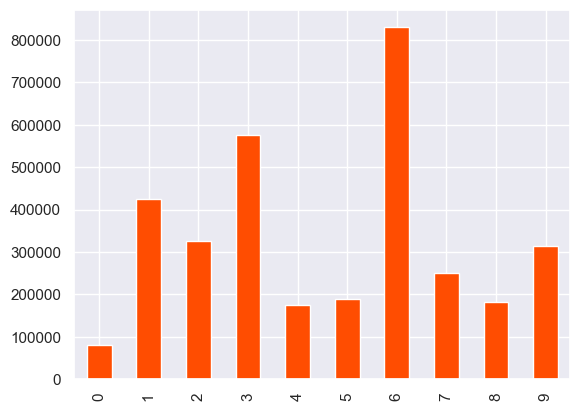

In [20]:
cl1=['#ff4d01','#000000']
sns.set_theme(style='darkgrid',palette=cl1)
df3['price'].head(10).plot(kind='bar')
plt.savefig("p1.png",dpi=1000)
plt.show()

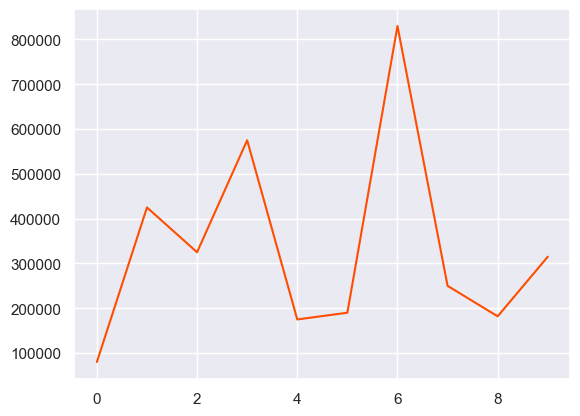

In [21]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='darkgrid',palette=cl1)
df3['price'].head(10).plot(kind='line')
plt.savefig("p2.png",dpi=1000)
plt.show()

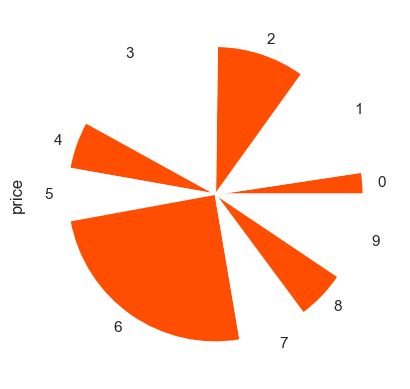

In [22]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
df3['price'].head(10).plot(kind='pie')
plt.savefig("p3.png",dpi=1000)
plt.show()

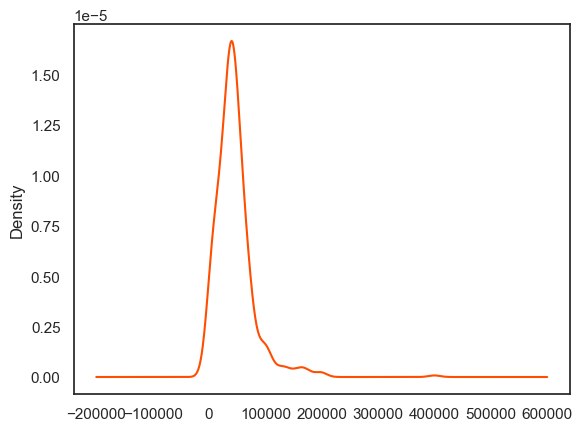

In [23]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='white',palette=cl1)
df3['kms_driven'].head(500).plot(kind='kde')
plt.savefig("p4.png",dpi=1000)
plt.show()

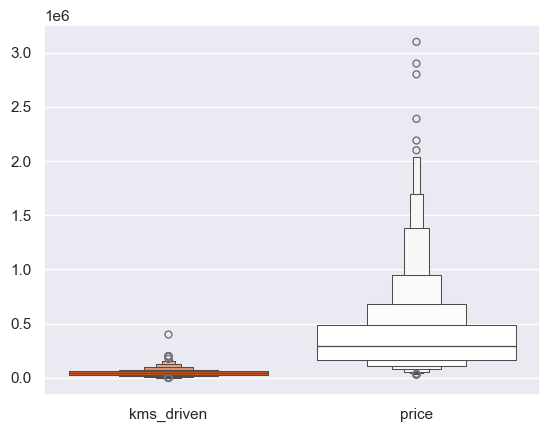

In [24]:
cl1=['#ff4d01','#ffffff']
sns.set_theme(style='darkgrid',palette=cl1)
sns.boxenplot(df2[['kms_driven','price']])
plt.savefig("p5.png",dpi=1000)
plt.show()

In [25]:
df3.isna().sum()

year                 0
kms_driven           0
fuel_type_encoded    0
company_encoded      0
price                0
dtype: int64

In [26]:
df3.isnull().sum()

year                 0
kms_driven           0
fuel_type_encoded    0
company_encoded      0
price                0
dtype: int64

In [27]:
numeric_columsn=df2.select_dtypes(include='number',exclude='object')
print(numeric_columsn.columns)

Index(['year', 'price', 'kms_driven', 'fuel_type_encoded', 'company_encoded'], dtype='object')


In [28]:
class AnomoliesDetection:
    def __init__(self,data):
        self.data=data
    def anomolies_function(self):
        Q1=self.data.quantile(0.25)
        Q3=self.data.quantile(0.75)
        IQR=Q3-Q1
        lower_bound=Q1-1.5*IQR 
        upper_bound=Q3+1.5*IQR
        anomolies=self.data[(self.data < lower_bound) | (self.data > upper_bound)]
        clean_data=self.data[(self.data >=lower_bound ) & (self.data <= upper_bound)]
        return clean_data,anomolies.tolist()
    
    
instance=AnomoliesDetection(df2['kms_driven'])
clean_data1,anomolies_data=instance.anomolies_function()
print(clean_data1)     

0      45000
1         40
2      28000
3      36000
4      41000
       ...  
809    45000
810    50000
811    30000
813    27000
814    40000
Name: kms_driven, Length: 688, dtype: int64


In [29]:
df3_clean= df2[~anomolies_data1]

NameError: name 'anomolies_data1' is not defined

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

cata=['Maruti',
 'Hyundai',
 'Mahindra',
 'Tata',
 'Honda',
 'Toyota',
 'Chevrolet',
 'Renault',
 'Ford',
 'Volkswagen',
 'Skoda',
 'Audi',
 'BMW',
 'Nissan',
 'Datsun',
 'Mercedes',
 'Mitsubishi',
 'Fiat',
 'Hindustan',
 'Mini',
 'Force',
 'Jaguar',
 'Land',
 'Jeep',
 'Volvo']
ordinal_encoding=OrdinalEncoder(categories=df2['company'],handle_unknown='use_encoded_value',unknown_value=100,encoded_missing_value=111)
df2['company_encoed']=ordinal_encoding.fit_transform()

In [30]:
df2.sample(10)

,company,year,price,kms_driven,fuel_type,fuel_type_encoded,company_encoded
393,Maruti,2001,40000,40000,Petrol,1,1
405,Mahindra,2018,1000000,4500,Diesel,2,3
191,Maruti,2011,145000,41000,Petrol,1,1
586,Tata,2012,210000,75000,Diesel,2,4
352,Mahindra,2016,1130000,72000,Diesel,2,3
523,Ford,2017,580000,10000,Petrol,1,9
638,Tata,2018,450000,102563,Diesel,2,4
194,Maruti,2013,125000,39000,Petrol,1,1
565,Renault,2015,385000,51000,Diesel,2,8
115,Maruti,2013,399999,33000,Diesel,2,1


In [32]:
df3=pd.DataFrame(data=df2,columns=['year','kms_driven','fuel_type_encoded','company_encoded','price'])

df3.head(10)

,year,kms_driven,fuel_type_encoded,company_encoded,price
0,2007,45000,1,2,80000
1,2006,40,2,3,425000
2,2014,28000,1,2,325000
3,2014,36000,2,9,575000
4,2012,41000,2,9,175000
5,2013,25000,1,2,190000
6,2016,24530,2,9,830000
7,2015,60000,1,1,250000
8,2010,60000,1,11,182000
9,2015,30000,1,1,315000


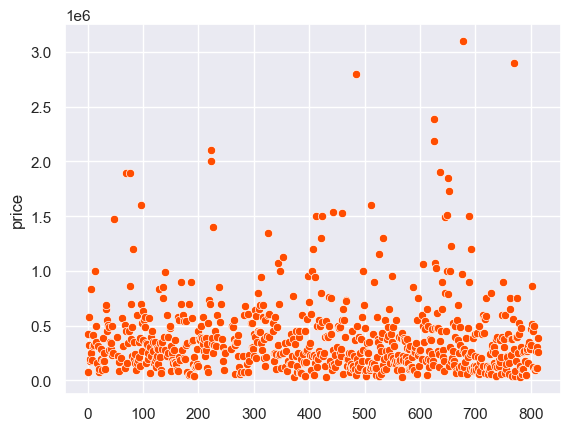

In [ ]:
cl1=['#ff4d01','#ffffff']

sns.scatterplot(df3['price'])
plt.savefig("p6.png",dpi=1000)
plt.show()